**UMAP for visualization**: @article{mcinnes2018umap,
  title={Umap: Uniform manifold approximation and projection for dimension reduction},
  author={McInnes, Leland and Healy, John and Melville, James},
  journal={arXiv preprint arXiv:1802.03426},
  year={2018}
}, @article{mcinnes2018umap-software,
  title={UMAP: Uniform Manifold Approximation and Projection},
  author={McInnes, Leland and Healy, John and Saul, Nathaniel and Grossberger, Lukas},
  journal={The Journal of Open Source Software},
  volume={3},
  number={29},
  pages={861},
  year={2018}
}

Different age groups

Explained variance ratio: [9.99780927e-01 1.18159035e-04]
PCA components (weights):
    sdNN_ms   samp_en  dfa_alpha1  hrv7_Cardiac
0  0.000326  0.000503   -0.000520      1.000000
1  0.929216 -0.355895   -0.099478     -0.000176


C:\Users\34673\miniconda3\envs\tf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


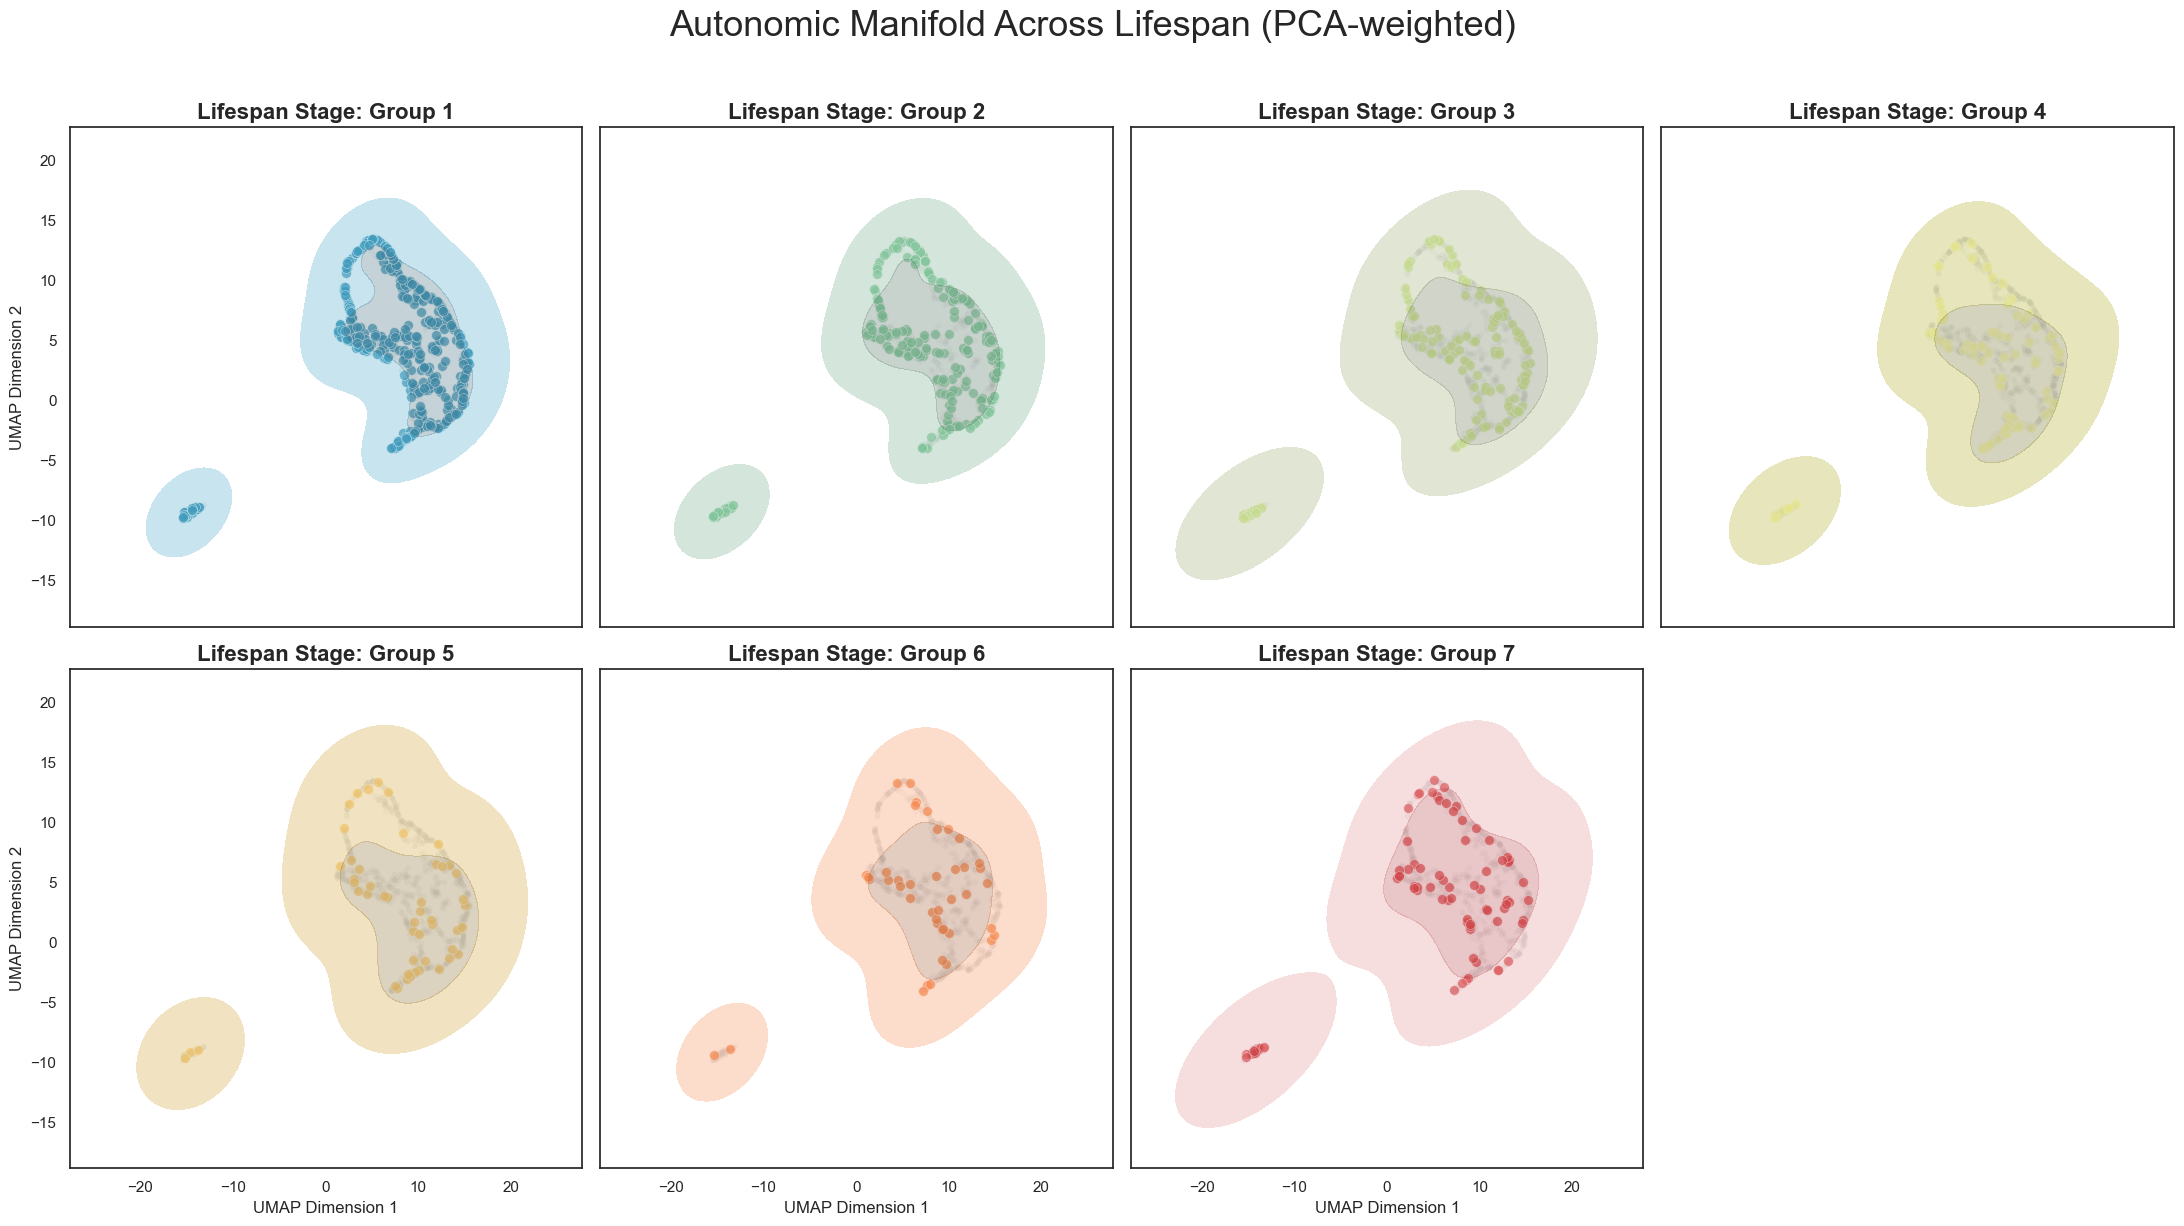

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import umap

# --- 1. Load and Merge Data ---
df_linear = pd.read_csv('final_hrv_linear_results.csv')
df_nonlinear = pd.read_csv('final_hrv_non_linear_results.csv')
df_influence = pd.read_csv('hr_influence_results.csv')
df_meta = pd.read_csv('analysis_groups.csv')

# Standardize IDs
for df in [df_linear, df_nonlinear, df_influence, df_meta]:
    if 'Patient_ID' in df.columns:
        df.rename(columns={'Patient_ID': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.lstrip('0')

# Merge datasets
df_master = pd.merge(df_meta, df_linear, on='ID', how='inner')
df_master = pd.merge(df_master, df_nonlinear, on='ID', how='inner')
df_master = pd.merge(df_master, df_influence[['ID', 'hrv7_Cardiac']], on='ID', how='inner')

# --- 2. Feature Selection ---
features = ['sdNN_ms', 'samp_en', 'dfa_alpha1','hrv7_Cardiac']
df_clean = df_master.dropna(subset=features + ['HRV_Age_Group']).copy()

X = df_clean[features].copy()

# --- 3. Robust Scaling ---
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. PCA (Data-driven weighting) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PCA components (weights):")
print(pd.DataFrame(pca.components_, columns=features))

# --- 5. UMAP on PCA space ---
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(X_pca)

df_clean['U1'], df_clean['U2'] = embedding[:, 0], embedding[:, 1]

# --- 6. Visualization ---
age_groups = sorted(df_clean['HRV_Age_Group'].unique())
n_groups = len(age_groups)

cols = 4
rows = (n_groups // cols) + (1 if n_groups % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(22, 6 * rows), sharex=True, sharey=True)
axes = axes.flatten()

sns.set_theme(style="white")
colors = sns.color_palette("Spectral_r", n_colors=n_groups)

for i, group in enumerate(age_groups):
    ax = axes[i]

    # Background population
    ax.scatter(df_clean['U1'], df_clean['U2'],
               c='lightgray', s=10, alpha=0.1)

    # Group data
    group_data = df_clean[df_clean['HRV_Age_Group'] == group]

    ax.scatter(group_data['U1'], group_data['U2'],
               color=colors[i], s=50, alpha=0.7,
               edgecolor='white', lw=0.5)

    # KDE only if enough samples
    if len(group_data) > 30:
        sns.kdeplot(data=group_data,
                    x='U1', y='U2',
                    color=colors[i],
                    levels=3,
                    alpha=0.3,
                    fill=True,
                    ax=ax)

    # Labels
    ax.set_title(f"Lifespan Stage: Group {int(group)}",
                 fontsize=16, fontweight='bold')
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.grid(False)

# Turn off empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Autonomic Manifold Across Lifespan (PCA-weighted)",
             fontsize=26, y=1.02)

plt.tight_layout()
plt.show()

C:\Users\34673\miniconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


<Axes: xlabel='U1', ylabel='U2'>

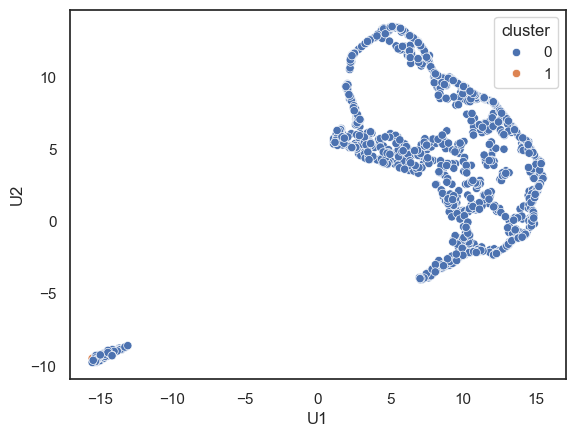

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_pca)

sns.scatterplot(data=df_clean, x='U1', y='U2', hue='cluster') #separation created by hrv7

In [18]:

from sklearn.cluster import KMeans

# 1. Create 3 clusters based on the UMAP positions (U1, U2)
# These represent: Young/Healthy, Transition, and Decoupled/Risk
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['cluster'] = kmeans.fit_transform(df_clean[['U1', 'U2']]).argmax(axis=1)


cluster_stats = df_clean.groupby('cluster')['hrv7_Cardiac'].describe()
print(cluster_stats)
cluster_stats2 = df_clean.groupby('cluster')['dfa_alpha1'].describe()
print(cluster_stats2)

         count          mean           std           min           25%  \
cluster                                                                  
1         86.0  1.575675e+51  4.877998e+51  1.038678e+50  1.875535e+50   
2        995.0  9.535502e+48  1.957733e+49  8.282348e+41  5.743500e+45   

                  50%           75%           max  
cluster                                            
1        3.180255e+50  8.432824e+50  3.868350e+52  
2        8.202018e+47  6.847819e+48  1.069169e+50  
         count      mean       std       min       25%       50%       75%  \
cluster                                                                      
1         86.0  0.813404  0.224341  0.421124  0.613095  0.819695  0.940160   
2        995.0  0.984373  0.248100  0.282119  0.823242  0.984785  1.149397   

              max  
cluster            
1        1.354940  
2        1.689409  


C:\Users\34673\miniconda3\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Comparing genders with aging

C:\Users\34673\miniconda3\envs\tf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


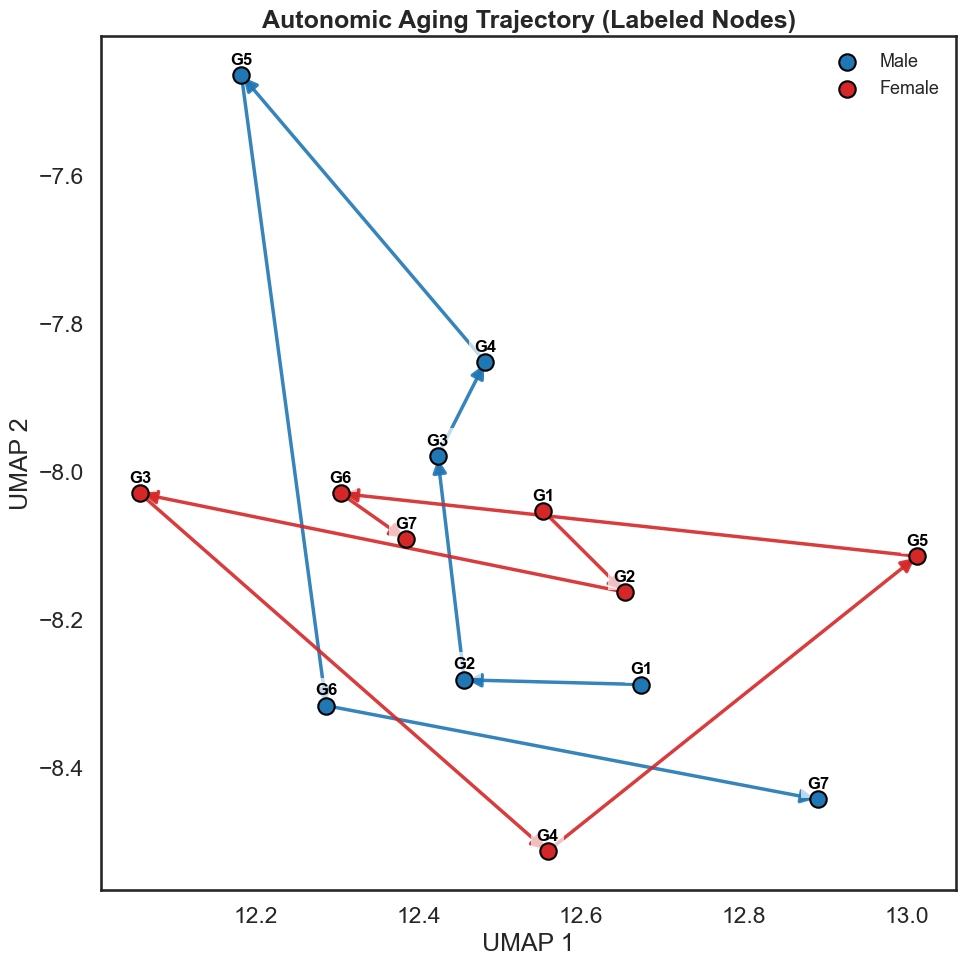

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import umap

# ================================
# 1. LOAD DATA
# ================================
df_linear = pd.read_csv('final_hrv_linear_results.csv')
df_nonlinear = pd.read_csv('final_hrv_non_linear_results.csv')
df_influence = pd.read_csv('hr_influence_results.csv')
df_meta = pd.read_csv('analysis_groups.csv')

# Standardize IDs
for df in [df_linear, df_nonlinear, df_influence, df_meta]:
    if 'Patient_ID' in df.columns:
        df.rename(columns={'Patient_ID': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.lstrip('0')

# Merge
df_master = pd.merge(df_meta, df_linear, on='ID', how='inner')
df_master = pd.merge(df_master, df_nonlinear, on='ID', how='inner')
df_master = pd.merge(df_master, df_influence[['ID', 'hrv7_Cardiac']], on='ID', how='inner')

# ================================
# 2. FEATURES
# ================================
features = ['sdNN_ms', 'samp_en', 'dfa_alpha1', 'hrv7_Cardiac']

df_clean = df_master.dropna(subset=features + ['Sex_Label', 'HRV_Age_Group']).copy()

# ================================
# 3. SCALING
# ================================
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_clean[features])

# ================================
# 4. PCA
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ================================
# 5. UMAP
# ================================
reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.05,
    metric='correlation',
    random_state=42
)

embedding = reducer.fit_transform(X_pca)

df_clean['U1'] = embedding[:, 0]
df_clean['U2'] = embedding[:, 1]

# ================================
# PLOT: TRAJECTORY + LABELS ON POINTS
# ================================
fig, ax = plt.subplots(figsize=(10, 10))
sns.set_theme(style="white", context="talk")

colors = {'Male': '#1f77b4', 'Female': '#d62728'}

for sex in ['Male', 'Female']:
    subset = df_clean[df_clean['Sex_Label'] == sex]

    path = subset.groupby('HRV_Age_Group')[['U1', 'U2']].median().sort_index()

    # Plot points
    ax.scatter(
        path['U1'], path['U2'],
        color=colors[sex],
        s=140,
        edgecolor='black',
        zorder=5,
        label=sex
    )

    # ARROWS (REAL TRANSITIONS)
    for i in range(len(path) - 1):
        x0, y0 = path.iloc[i]
        x1, y1 = path.iloc[i + 1]

        ax.annotate(
            '',
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle='-|>',
                color=colors[sex],
                lw=2.5,
                mutation_scale=20,
                alpha=0.9
            )
        )

    # LABELS ON TOP OF POINTS (G1, G2, G3...)
    for i, (group, row) in enumerate(path.iterrows(), start=1):
        ax.text(
            row['U1'],
            row['U2'] + 0.01,  # pequeño offset para que no tape el punto
            f"G{i}",
            fontsize=12,
            fontweight='bold',
            ha='center',
            va='bottom',
            color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

ax.set_title("Autonomic Aging Trajectory (Labeled Nodes)", fontsize=18, fontweight='bold')
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

ax.legend(frameon=False, fontsize=13)

plt.tight_layout()
plt.show()


In [27]:
np.linalg.norm(path.diff().dropna(), axis=1) #velocity of aging, g1->g2, g2->3...

array([0.14845853, 0.6104051 , 0.6962878 , 0.604473  , 0.7135053 ,
       0.10155892], dtype=float32)

Physical activity analysis

C:\Users\34673\miniconda3\envs\tf\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\34673\AppData\Local\Temp\ipykernel_29204\2764001274.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['UMAP1'], df_clean['UMAP2'] = embedding[:, 0], embedding[:, 1]
C:\Users\34673\AppData\Local\Temp\ipykernel_29204\2764001274.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['UMAP1'], df_clean['UMAP2

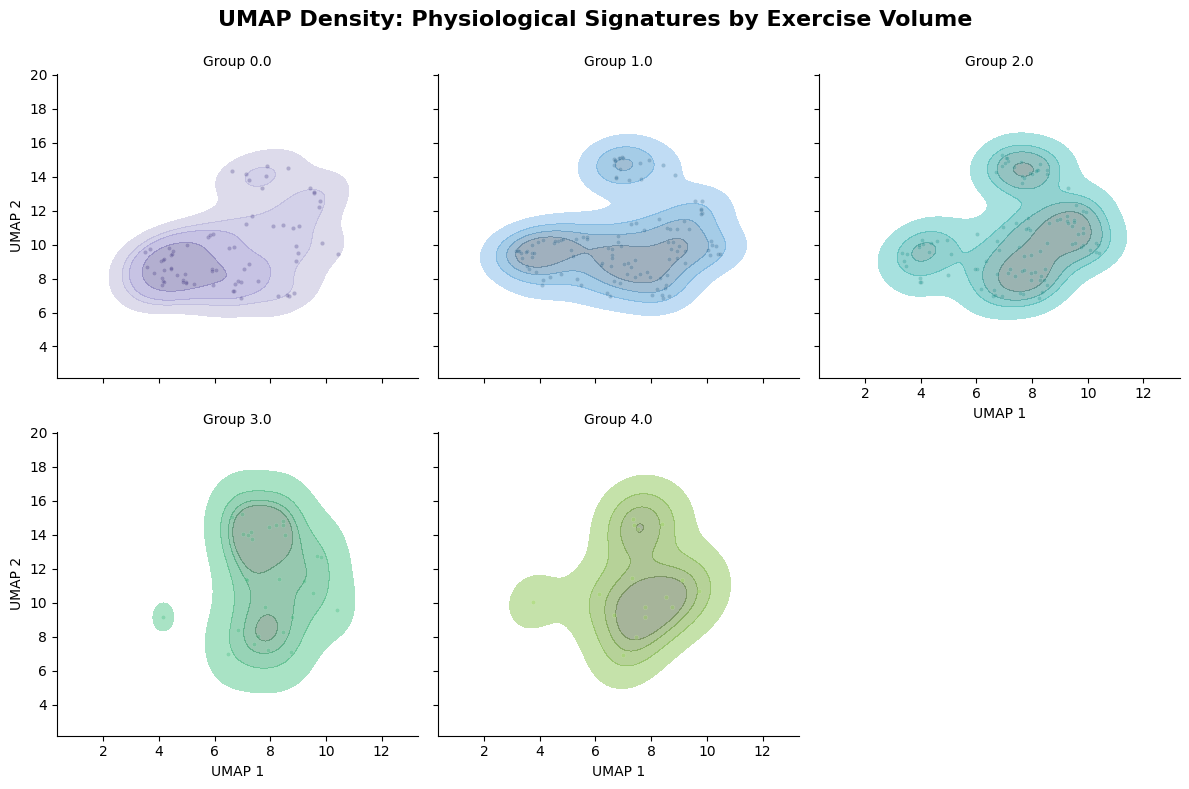

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import os

# 1. Setup paths
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"
ex_hours_col = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'

# 2. Load and Merge
df_linear = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
df_nonlin = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
df_exercise = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))
df_subject = pd.read_csv(os.path.join(path, 'subject-info.csv'))

df = pd.merge(pd.merge(df_linear, df_nonlin, on='Patient_ID'), 
              pd.merge(df_exercise.rename(columns={'ID':'Patient_ID'}), 
                       df_subject.rename(columns={'ID':'Patient_ID'}), on='Patient_ID'), on='Patient_ID')

# 3. Clean and Scale
features = ['Age', 'BMI', 'rmssd_ms', 'HFn', 'pNN50_pct', 'meanNN_ms'] #using vagal set
for col in features + [ex_hours_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=features + [ex_hours_col])
X = StandardScaler().fit_transform(df_clean[features])

# 4. Run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X)
df_clean['UMAP1'], df_clean['UMAP2'] = embedding[:, 0], embedding[:, 1]

# 5. VISUALIZATION: Faceted Density Contours
# We use 'kdeplot' inside the grid to show where the "mass" of each group lies
g = sns.FacetGrid(df_clean, col=ex_hours_col, col_wrap=3, height=4, hue=ex_hours_col, palette='viridis')

# Draw the density contours
g.map(sns.kdeplot, 'UMAP1', 'UMAP2', fill=True, alpha=0.5, levels=5, thresh=0.1)

# Draw the actual points on top but very small and faint
g.map(sns.scatterplot, 'UMAP1', 'UMAP2', alpha=0.3, s=10)

g.set_axis_labels("UMAP 1", "UMAP 2")
g.set_titles(col_template="Group {col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('UMAP Density: Physiological Signatures by Exercise Volume', fontsize=16, fontweight='bold')

plt.show()